# Analisi Diffusione COVID-19
## Il committente richiede di avere un report su casi e vaccinazioni in diverse aree del mondo; a tal fine, richiede di utilizzare i dati, raccolti e curati da Our World in Data
### 1) Si richiede di verificare le dimensioni del dataset e i relativi metadati
---
# IMPORT

In [33]:
#Importo le librerie 

import os
import dotenv
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px

In [34]:
# carico le variabili d'ambiente dal file .env

dotenv.load_dotenv()

# Recupero la variabile COVID_PATH dal file .env
# os.getenv() legge il valore associato alla chiave "COVID_PATH"

pathcovid = os.getenv("COVID_PATH")

# Leggo il file CSV indicato dal path e lo salvo in un DataFrame Pandas
# pd.read_csv() apre il file e lo trasforma in una tabella (DataFrame)

df_covid = pd.read_csv(pathcovid)


In [54]:
# Carico il dataset

df_covid = pd.read_csv(pathcovid)

# Estraggo numero di righe e colonne

righe, colonne = df_covid.shape

# Stampo info principali

print("le righe sono:", righe)
print("le colonne sono:", colonne)
print("i nomi delle colonne sono", df_covid.columns)

# Mostro 10 righe casuali, oppure uso .head(10) e mostro le prime 10

print("Anteprima")
df_covid.sample(10)


le righe sono: 429435
le colonne sono: 67
i nomi delle colonne sono Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
178508,IRN,Asia,Iran,2024-05-26,7627863.0,0.0,0.00,146837.0,0.0,0.00,...,21.1,NaN,1.50,76.68,0.78,88550568,NaN,NaN,NaN,NaN
336249,SAU,Asia,Saudi Arabia,2020-03-23,392.0,0.0,41.29,0.0,0.0,0.00,...,25.4,NaN,2.70,75.13,0.85,36408824,NaN,NaN,NaN,NaN
281945,MKD,Europe,North Macedonia,2023-11-17,349971.0,0.0,8.14,9960.0,0.0,0.14,...,NaN,NaN,4.28,75.80,0.77,2093606,NaN,NaN,NaN,NaN
337899,OWID_SCT,Europe,Scotland,2020-04-30,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,5466000,NaN,NaN,NaN,NaN
370478,SWE,Europe,Sweden,2023-04-15,2702703.0,0.0,145.14,23926.0,0.0,6.71,...,18.9,NaN,2.22,82.80,0.94,10549349,NaN,NaN,NaN,NaN
220476,OWID_LMC,NaN,Lower-middle-income countries,2022-11-01,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3432097300,NaN,NaN,NaN,NaN
259137,MMR,Asia,Myanmar,2021-01-12,130604.0,0.0,608.43,2846.0,0.0,16.86,...,35.2,79.29,0.90,67.13,0.58,54179312,NaN,NaN,NaN,NaN
375112,TWN,Asia,Taiwan,2022-04-03,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,80.46,NaN,23893396,NaN,NaN,NaN,NaN
409250,OWID_UMC,NaN,Upper-middle-income countries,2023-01-21,245160405.0,0.0,372687.14,2744726.0,0.0,234.86,...,NaN,NaN,NaN,NaN,NaN,2525921300,NaN,NaN,NaN,NaN
169808,HKG,Asia,Hong Kong,2023-07-15,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,84.86,0.95,7488863,NaN,NaN,NaN,NaN


In [36]:
# Controllo i metadati del dataset (tipi di dato, valori non nulli, struttura)

df_covid.info()

print("---------------------------------------------------")
print("---------------------------------------------------")

# Controllo i valori mancanti per colonna e li ordino per gravità

df_covid.isna().sum().sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

weekly_icu_admissions_per_million          418442
weekly_icu_admissions                      418442
excess_mortality_cumulative_per_million    416024
excess_mortality                           416024
excess_mortality_cumulative                416024
                                            ...  
total_deaths                                17631
population                                      0
date                                            0
location                                        0
iso_code                                        0
Length: 67, dtype: int64

In [37]:
# Converto la colonna 'date' in formato datetime per poter fare analisi temporali

df_covid["date"] = pd.to_datetime(df_covid["date"])

# controllo che la conversione sia avvenuta corretamente

df_covid["date"].dtype.name 

'datetime64[ns]'

## 2) Si chiede di trovare, per ogni continente
### a) Il numero di casi fin dall'inizio della pandemia

In [38]:
# Tengo solo i paesi (gli aggregati hanno continent = NaN)

df_paesi = df_covid[df_covid["continent"].notna()]

# Totale finale dei casi per ogni paese

totali_per_paese = (df_paesi.groupby(["continent", "location"])
    ["total_cases"].max())    # total_cases è cumulativo quindi max = totale finale


# Somma dei paesi dentro ogni continente ordinati

totali_continente = (totali_per_paese
        .groupby("continent")
        .sum().sort_values(ascending = False))

print("Numero di casi dal inzio della pandemia per continente")
totali_continente.to_frame()

Numero di casi dal inzio della pandemia per continente


,total_cases
continent,
Asia,301532347.0
Europe,252916868.0
North America,124492666.0
South America,68809418.0
Oceania,15003352.0
Africa,13145540.0


## 2) Si chiede di trovare, per ogni continente
### b) La percentuale rispetto al totale mondiale del numero di casi

In [39]:
# Calcolo il totale mondiale dei casi e la percentuale dei casi per continente

totale_mondo = df_covid[df_covid["location"] == "World"]["total_cases"].max()
percentuali_continente = (totali_continente / totale_mondo) * 100

print("Il totale mondiale dei casi è:", totale_mondo)
print("Le percentuali dei casi rispetto al totale per continente sono:")

# Mostro le percentuali formattate con il simbolo %

percentuali_continente.round(2).to_frame().style.format("{:.2f}%")

Il totale mondiale dei casi è: 775866783.0
Le percentuali dei casi rispetto al totale per continente sono:


,total_cases
continent,
Asia,38.86%
Europe,32.60%
North America,16.05%
South America,8.87%
Oceania,1.93%
Africa,1.69%


In [40]:
# confronto tra totale del mondo e totale dei continenti

totale_continenti = totali_continente.sum()

print("totale mondo:", totale_mondo) 
print("totale continenti:", totale_continenti)

totale mondo: 775866783.0
totale continenti: 775900191.0


# Eseguendo queste analisi ho riscontrato che: 
### la somma dei casi per continente non coincide con il totale mondiale. OWID stesso specifica che non garantisce coerenza perfetta tra aggregati: i totali di continenti e regioni non sono sincronizzati con il totale “World”. Questo spiega le piccole discrepanze osservate nei dati.
---
# 3) Selezionare i dati relativi all'Italia nel 2022 
## Poiché i nuovi casi vengono registrati settimanalmente, filtrare via i giorni che non hanno misurazioni; quindi mostrare con dei grafici adeguati: 
### a) L'evoluzione del casi totali dall'inizio alla fine dell'anno

In [41]:
# Estraggo l'anno dalla colonna 'date' e lo salvo in una nuova colonna 'year'

df_covid["year"] = df_covid["date"].dt.year

# Seleziono i dati relativi all'Italia nell'anno 2022

italia_2022 = df_covid[
    (df_covid["location"] == "Italy") &
    (df_covid["year"] == 2022)
]

# Pulisco il dataset rimuovendo i giorni con valori mancanti o pari a zero nei nuovi casi

italia_2022_pulito = italia_2022[italia_2022["new_cases"].notna() & (italia_2022["new_cases"] > 0)]



# Visualizzo le prime 10 righe per verificare il risultato del filtraggio

italia_2022_pulito.head(10)


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million,year
186003,ITA,Europe,Italy,2022-01-02,6267035.0,644604.0,92086.29,137513.0,983.0,140.43,...,NaN,3.18,83.51,0.89,59037472,168226.30,12.99,8.06,2849.48,2022
186010,ITA,Europe,Italy,2022-01-09,7281297.0,1014262.0,144894.57,138881.0,1368.0,195.43,...,NaN,3.18,83.51,0.89,59037472,168831.80,12.89,3.94,2859.74,2022
186017,ITA,Europe,Italy,2022-01-16,8549450.0,1268153.0,181164.71,140856.0,1975.0,282.14,...,NaN,3.18,83.51,0.89,59037472,170089.10,12.83,8.03,2881.04,2022
186024,ITA,Europe,Italy,2022-01-23,9781191.0,1231741.0,175963.00,143296.0,2440.0,348.57,...,NaN,3.18,83.51,0.89,59037472,171694.19,12.80,10.40,2908.22,2022
186031,ITA,Europe,Italy,2022-01-30,10821375.0,1040184.0,148597.71,145914.0,2618.0,374.00,...,NaN,3.18,83.51,0.89,59037472,174151.69,12.84,16.50,2949.85,2022
186038,ITA,Europe,Italy,2022-02-06,11542793.0,721418.0,103059.71,148542.0,2628.0,375.43,...,NaN,3.18,83.51,0.89,59037472,176219.19,12.85,13.98,2984.87,2022
186045,ITA,Europe,Italy,2022-02-13,12053330.0,510537.0,72933.86,150824.0,2282.0,326.00,...,NaN,3.18,83.51,0.89,59037472,177489.48,12.81,8.88,3006.39,2022
186052,ITA,Europe,Italy,2022-02-20,12427773.0,374443.0,53491.86,152848.0,2024.0,289.14,...,NaN,3.18,83.51,0.89,59037472,178007.39,12.72,3.66,3015.16,2022
186059,ITA,Europe,Italy,2022-02-27,12732680.0,304907.0,43558.14,154416.0,1568.0,224.00,...,NaN,3.18,83.51,0.89,59037472,178015.30,12.60,0.06,3015.29,2022
186066,ITA,Europe,Italy,2022-03-06,12990223.0,257543.0,36791.86,155782.0,1366.0,195.14,...,NaN,3.18,83.51,0.89,59037472,178133.80,12.48,0.86,3017.30,2022


In [42]:
# Controllo la struttura del dataset pulito (Italia 2022):
# - numero di righe e colonne
# - tipi di dato
# - conteggio dei valori non nulli

italia_2022_pulito.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52 entries, 186003 to 186360
Data columns (total 68 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   iso_code                                    52 non-null     object        
 1   continent                                   52 non-null     object        
 2   location                                    52 non-null     object        
 3   date                                        52 non-null     datetime64[ns]
 4   total_cases                                 52 non-null     float64       
 5   new_cases                                   52 non-null     float64       
 6   new_cases_smoothed                          52 non-null     float64       
 7   total_deaths                                52 non-null     float64       
 8   new_deaths                                  52 non-null     float64       
 9   new_deat

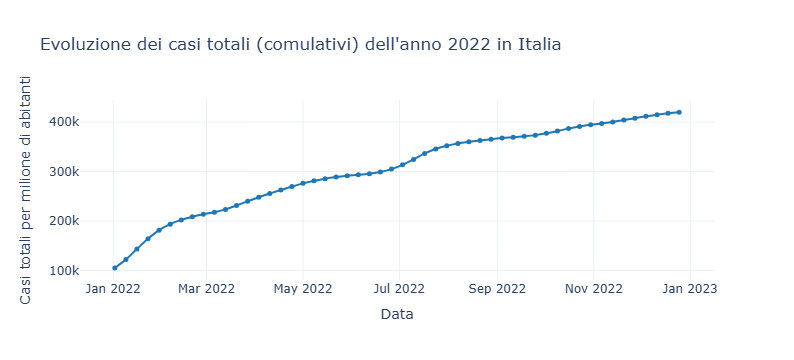

In [43]:
# Grafico lineare dei casi totali in Italia nel 2022

fig_ita_2022_tot = px.line(
    italia_2022_pulito,
    x="date",                # Variabile sull'asse X andamento temporale
    y="total_cases_per_million",         # Variabile sull'asse Y casi totali cumulativi
    title="Evoluzione dei casi totali (comulativi) dell'anno 2022 in Italia",  # Titolo del grafico
    markers=True,            # Mostra i punti reali dei dati 
    line_shape="spline",     # Rende la linea più morbida e continua
    color_discrete_sequence=["#1f77b4"]  # Imposta un colore  pulito
)

#  Parametri Layout 

fig_ita_2022_tot.update_layout(
    template="plotly_white",  # Tema chiaro e minimale
    xaxis_title="Data",       # Etichetta asse X
    yaxis_title="Casi totali per milione di abitanti",# Etichetta asse Y
    hovermode="x unified"     # Tooltip unico per ogni data (molto utile)
)

#  Parametri linea

fig_ita_2022_tot.update_traces(
    line=dict(width=2),       # Spessore della linea
    marker=dict(size=5)       # Dimensione dei marker
)

fig_ita_2022_tot.show()       # visualizzo il grafioco


### Il grafico mostra l’andamento cumulativo dei casi totali di COVID‑19 in Italia nel 2022, evidenziando una crescita rapida nei primi mesi e più graduale nella seconda parte dell’anno.
---
# 3) Selezionare i dati relativi all'Italia nel 2022 
##  quindi mostrare con dei grafici adeguati:
### b) Il numero di nuovi casi rispetto alla data

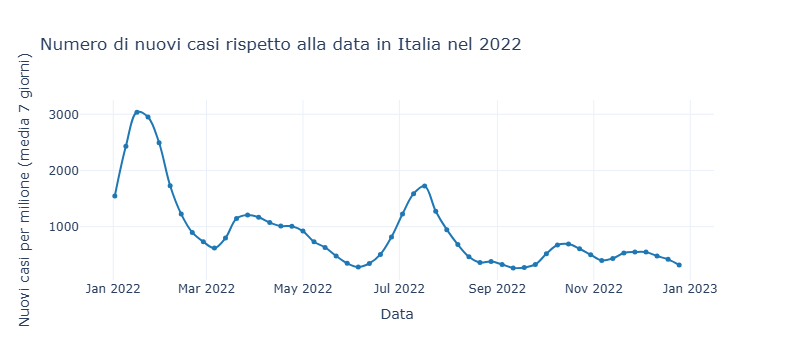

In [44]:
# Grafico dei nuovi casi COVID in Italia nel 2022

fig_ita_2022_nuovi = px.line(
    italia_2022_pulito,
    x="date",                 # Asse X → andamento temporale giorno per giorno
    y="new_cases_smoothed_per_million",            # Asse Y nuovi casi registrati settimanalmente
    title="Numero di nuovi casi rispetto alla data in Italia nel 2022",  # Titolo del grafico
    markers=True,             # Mostra i punti reali della serie 
    line_shape="spline",      # Rende la linea più morbida e continua
    color_discrete_sequence=["#1f77b4"]  # Imposta un colore pulito
)

# Parametri del Layout 

fig_ita_2022_nuovi.update_layout(
    template="plotly_white",  # Tema chiaro e minimale
    xaxis_title="Data",       # Etichetta asse X
    yaxis_title="Nuovi casi per milione (media 7 giorni)", # Etichetta asse Y
    hovermode="x unified"     # Tooltip unico per ogni data 
)

# Parametri della linea 

fig_ita_2022_nuovi.update_traces(
    line=dict(width=2),       # Spessore della linea
    marker=dict(size=5)       # Dimensione dei marker
)

fig_ita_2022_nuovi.show()     # visualizzo il grafico


### Il grafico mostra l’andamento dei nuovi casi di COVID‑19 in Italia nel 2022, si notano chiaramente le principali ondate epidemiche: una forte impennata a gennaio‑febbraio, seguita da altre più contenute in estate e autunno.
___
# Eseguendo questa analisi:
### Ho utilizzato le colonne per milione (total_cases_per_million, new_cases_smoothed_per_million) per rendere i dati proporzionati alla popolazione, così da poter confrontare l’intensità del contagio in modo realistico e non influenzato dal numero totale di abitanti.
___
# 4) Riguardo le nazioni di Italia, Germania e Francia: 
## a) Mostrare in un boxplot la differenza tra queste nazioni riguardo il numero di pazienti in terapia intensiva (Intensive Care Unit, ICU, considerare quindi la colonna icu_patients) da maggio 2022 (incluso) ad aprile 2023 (incluso)

In [45]:
# Seleziono solo Italia, Germania e Francia
# Limito il periodo da maggio 2022 ad aprile 2023 (inclusi)

df_icu = df_covid[
    (df_covid["location"].isin(["Italy", "Germany", "France"])) &
    (df_covid["date"].between("2022-05-01", "2023-04-30"))]

# Tengo solo le righe con icu_patients non mancanti

df_icu_pulito = df_icu[df_icu["icu_patients"].notna()]

# eseguo un controllo 

df_icu_pulito[["location","icu_patients"]].sample(10)

,location,icu_patients
131531,France,760.0
186342,Italy,337.0
141581,Germany,1221.0
186232,Italy,260.0
141548,Germany,778.0
186282,Italy,194.0
141382,Germany,767.0
131323,France,981.0
141599,Germany,843.0
186162,Italy,196.0


In [46]:
# Controllo la struttura del dataset 
# - numero di righe e colonne
# - tipi di dato
# - conteggio dei valori non nulli

df_icu_pulito.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1065 entries, 131214 to 186486
Data columns (total 68 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   iso_code                                    1065 non-null   object        
 1   continent                                   1065 non-null   object        
 2   location                                    1065 non-null   object        
 3   date                                        1065 non-null   datetime64[ns]
 4   total_cases                                 1065 non-null   float64       
 5   new_cases                                   1065 non-null   float64       
 6   new_cases_smoothed                          1065 non-null   float64       
 7   total_deaths                                1065 non-null   float64       
 8   new_deaths                                  1065 non-null   float64       
 9   new_de

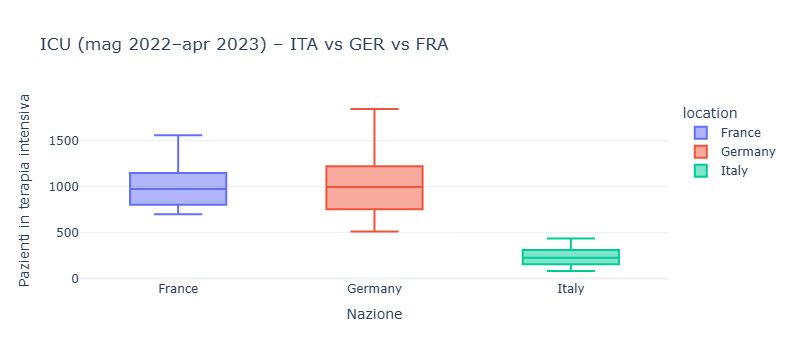

In [47]:
# Boxplot di confronto pazzienti in terapia intesiva Ita,Ger,Fra nel 2022

fig_icu_2022 = px.box(
    df_icu_pulito,          # Il DataFrame 
    x="location",           # Le categorie sull'asse X (Italia, Germania, Francia)
    y="icu_patients",       # La variabile numerica da confrontare nel boxplot
    title="ICU (mag 2022–apr 2023) – ITA vs GER vs FRA",     # Titolo del grafico
    color="location",       # Colori diversi per ogni nazione
)

# Parametri del layout

fig_icu_2022.update_layout(
    template="plotly_white",    # Stile grafico pulito e leggibile
    xaxis_title="Nazione",      # Etichetta asse X
    yaxis_title="Pazienti in terapia intensiva",  # Etichetta asse Y
)

fig_icu_2022.show()             # Visualizza il grafico


# b) scrivere un breve commento 
### Dal boxplot emerge che Germania e Francia presentano un numero di pazienti in terapia intensiva nettamente più elevato e variabile rispetto all’Italia, che invece mostra valori molto più bassi e stabili nel periodo considerato.
### In questo esercizio uso i valori assoluti (icu_patients) perché il confronto richiesto riguarda il numero reale di pazienti in terapia intensiva.
---
# 5) Riguardo le nazioni di Italia, Germania, Francia e Spagna in tutto il 2021:
## a) Mostrare, in maniera grafica oppure numerica, la somma dei pazienti ospitalizzati per ognuna (colonna hosp_patients)
## b) Se ci sono dati nulli, con un breve commento scrivere se puo essere possibile gestirli tramite sostituzione o meno

In [48]:
# Seleziono solo le righe relative a Italia, Germania, Francia e Spagna
# e solo per il periodo compreso tra il 1° gennaio e il 31 dicembre 2021.

df_2021 = df_covid[
    (df_covid["location"].isin(["Italy", "Germany", "France", "Spain"])) &
    (df_covid["date"] >= "2021-01-01") &
    (df_covid["date"] <= "2021-12-31")]

# Elimino le righe con valori nulli in 'hosp_patients'

df_2021 = df_2021[df_2021["hosp_patients"].notna()]

# eseguo un controllo

df_2021[["date","location","hosp_patients","hosp_patients_per_million"]].head(10)

,date,location,hosp_patients,hosp_patients_per_million
130729,2021-01-01,France,24263.0,357.79
130730,2021-01-02,France,24458.0,360.67
130731,2021-01-03,France,24780.0,365.42
130732,2021-01-04,France,24962.0,368.10
130733,2021-01-05,France,24871.0,366.76
130734,2021-01-06,France,24708.0,364.36
130735,2021-01-07,France,24488.0,361.11
130736,2021-01-08,France,24377.0,359.47
130737,2021-01-09,France,24240.0,357.45
130738,2021-01-10,France,24526.0,361.67


In [49]:
# Controllo la struttura del dataset 
# - numero di righe e colonne
# - tipi di dato
# - conteggio dei valori non nulli

df_2021[["location","hosp_patients","hosp_patients_per_million"]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1095 entries, 130729 to 363312
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   location                   1095 non-null   object 
 1   hosp_patients              1095 non-null   float64
 2   hosp_patients_per_million  1095 non-null   float64
dtypes: float64(2), object(1)
memory usage: 34.2+ KB


In [50]:
# Calcolo la somma totale dei pazienti ospedalizzati nel 2021 per ciascun paese

somma_hosp = df_2021.groupby("location")["hosp_patients"].sum()

print("Somma  dei pazienti ospedalizzati 2021")
somma_hosp.to_frame()

Somma  dei pazienti ospedalizzati 2021


,hosp_patients
location,
France,6008717.0
Italy,4419950.0
Spain,2411706.0


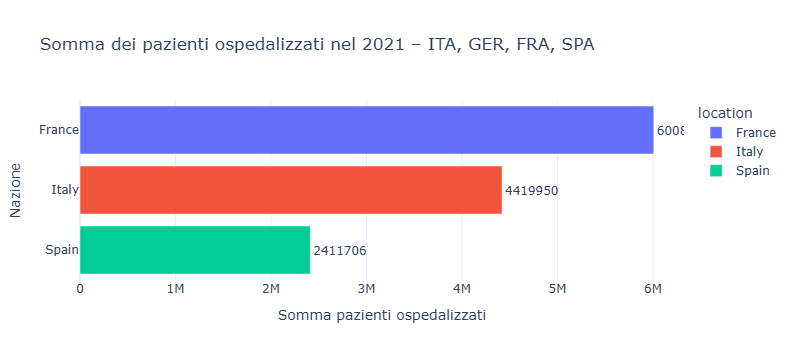

In [51]:
# grafico pazzienti ospedalizzati 2021 Ita,Fra,Spa,Ger

fig_hosp = px.bar(
    somma_hosp.reset_index(),   # converte l'indice in colonna per usarlo nel grafico
    x="hosp_patients",          # valori numerici sull'asse X (somma pazienti)
    y="location",               # categorie sull'asse Y (nazioni)
    orientation="h",            # barre orizzontali invece che verticali
    title="Somma dei pazienti ospedalizzati nel 2021 – ITA, GER, FRA, SPA",  # titolo del grafico
    color="location",           # colore diverso per ogni nazione
    text="hosp_patients"        # mostra il valore numerico accanto alla barra
)
       # parametri del layout

fig_hosp.update_layout(
    template="plotly_white",    # stile grafico chiaro e pulito
    xaxis_title="Somma pazienti ospedalizzati",  # etichetta asse X
    yaxis_title="Nazione",      # etichetta asse Y
)
      # Aggiorno tutte le tracce del grafico impostando la posizione del testo sopra le barre

fig_hosp.update_traces(
    textposition="outside"      # posiziona i valori fuori dalle barre
)

fig_hosp.show()                      # visualizza il grafico


### Il grafico rappresenta la somma totale dei pazienti ospedalizzati registrati nel 2021 per ciascuna nazione. Le barre orizzontali permettono di confrontare rapidamente quale Paese ha avuto il carico ospedaliero complessivo più elevato.
### Riscontro un'anomalia riguardo la Germania, i dati nel periodo relativo all'analisi sembrano essere tutti NaN
___

In [52]:
# Conto quanti valori NON nulli ha la Germania in 'hosp_patients' nel 2021

germany_2021 = df_covid[
    (df_covid["location"] == "Germany") &
    (df_covid["date"] >= "2021-01-01") &
    (df_covid["date"] <= "2021-12-31")
]

print("Somma di tutti i valori non nulli della colonna hosp_patients della Germania")
germany_2021["hosp_patients"].notna().sum()



Somma di tutti i valori non nulli della colonna hosp_patients della Germania


np.int64(0)

In [53]:
# eseguo un ulteriore controllo sulle colonne

germany_2021.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 140773 to 141137
Data columns (total 68 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   iso_code                                    365 non-null    object        
 1   continent                                   365 non-null    object        
 2   location                                    365 non-null    object        
 3   date                                        365 non-null    datetime64[ns]
 4   total_cases                                 365 non-null    float64       
 5   new_cases                                   365 non-null    float64       
 6   new_cases_smoothed                          365 non-null    float64       
 7   total_deaths                                365 non-null    float64       
 8   new_deaths                                  365 non-null    float64       
 9   new_dea

## b) Se ci sono dati nulli, con un breve commento scrivere se puo essere possibile gestirli tramite sostituzione o meno

### Poiché per la Germania nel 2021 la colonna hosp_patients è completamente vuota, la metrica più appropriata da utilizzare come sostituto è weekly_hosp_admissions, che rappresenta i nuovi ricoveri settimanali ed è l’unico indicatore ospedaliero completo e disponibile per tutto l’anno nel dataset OWID.